In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [89]:
import csv

BASE = '../imc-prosperity-4-backtester/prosperity4bt/resources/round1'
DAYS = ['-2', '-1', '0']

price_rows = []
trade_rows = []
offset = 0

for day in DAYS:
    with open(f'{BASE}/prices_round_1_day_{day}.csv') as f:
        for row in csv.DictReader(f, delimiter=';'):
            mid = row['mid_price']
            if not mid or float(mid) == 0:
                continue
            row['timestamp'] = int(row['timestamp']) + offset
            price_rows.append(row)

    with open(f'{BASE}/trades_round_1_day_{day}.csv') as f:
        for row in csv.DictReader(f, delimiter=';'):
            row['timestamp'] = int(row['timestamp']) + offset
            trade_rows.append(row)

    offset += 1_000_000

prices = pd.DataFrame(price_rows)
trades = pd.DataFrame(trade_rows)

for col in ['timestamp', 'bid_price_1', 'bid_volume_1', 'ask_price_1', 'ask_volume_1', 'mid_price']:
    prices[col] = pd.to_numeric(prices[col], errors='coerce')
trades['timestamp'] = pd.to_numeric(trades['timestamp'], errors='coerce')
trades['price']     = pd.to_numeric(trades['price'],     errors='coerce')
trades['quantity']  = pd.to_numeric(trades['quantity'],  errors='coerce')

print(prices['product'].unique())
print(f'prices rows: {len(prices)}  trades rows: {len(trades)}')

['INTARIAN_PEPPER_ROOT' 'ASH_COATED_OSMIUM']
prices rows: 59897  trades rows: 2276


In [90]:
groups_prices = prices.groupby('product')
aco_prices = groups_prices.get_group('ASH_COATED_OSMIUM')

trades.drop(columns=[c for c in ['buyer','seller','currency'] if c in trades.columns], inplace=True)
groups_trades = trades.groupby('symbol')
aco_trades = groups_trades.get_group('ASH_COATED_OSMIUM')

In [91]:
def plot_prices(prices_df, title=None):
    plt.close('all')
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(prices_df.timestamp, prices_df['mid_price'], linewidth=1.2, color='steelblue')
    for sep in [1_000_000, 2_000_000]:
        ax.axvline(sep, color='gray', lw=0.8, ls='--')
    for i, label in enumerate(['day -2', 'day -1', 'day 0']):
        ax.text(i * 1_000_000 + 20_000, ax.get_ylim()[0], label, fontsize=8, color='gray', va='bottom')
    ax.set_xlabel('Timestamp', fontsize=12)
    ax.set_ylabel('Price', fontsize=12)
    ax.set_title(title or 'Mid Price', fontsize=14)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

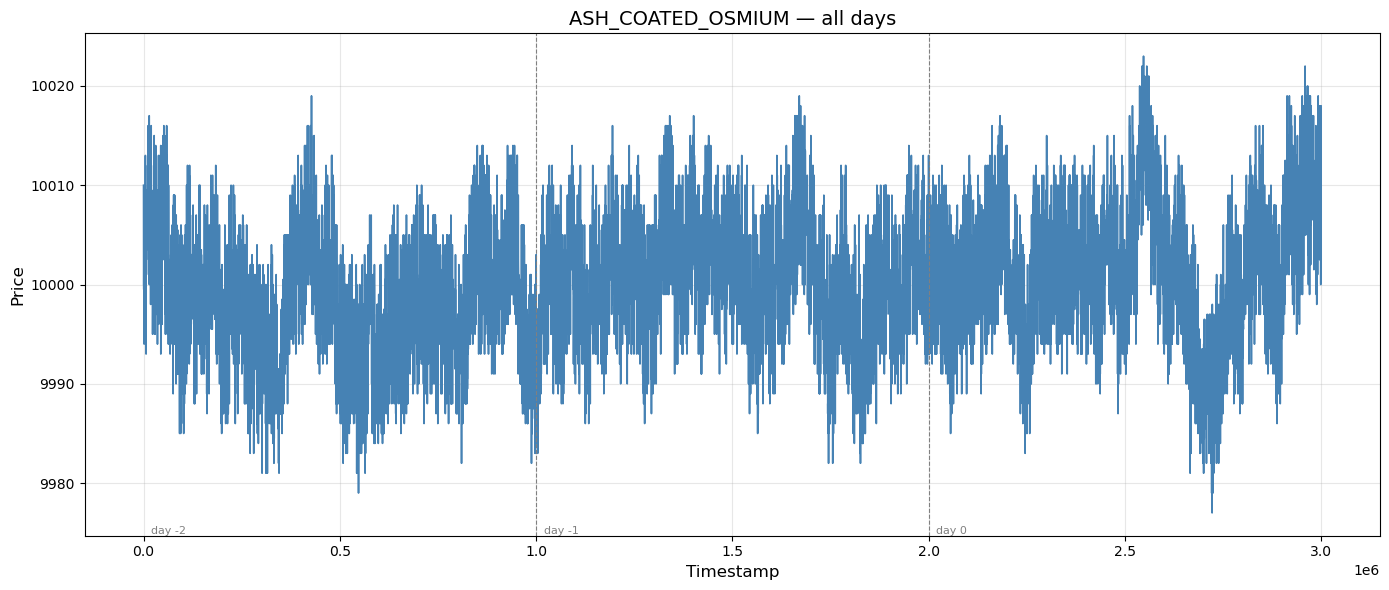

In [92]:
plot_prices(aco_prices, 'ASH_COATED_OSMIUM — all days')

In [93]:
def plot_trades(trades_df, title=None):
    plt.close('all')
    fig, ax = plt.subplots(figsize=(14, 6))
    q_min, q_max = trades_df['quantity'].min(), trades_df['quantity'].max()
    sizes = 20 + (trades_df['quantity'] - q_min) / max(q_max - q_min, 1) * 280
    ax.scatter(trades_df.timestamp, trades_df['price'], s=sizes,
               color='red', alpha=0.4, edgecolors='darkred', linewidth=0.3,
               label='Trades (size ∝ quantity)')
    ax.set_xlabel('Timestamp', fontsize=12)
    ax.set_ylabel('Price', fontsize=12)
    ax.set_title(title or 'Trades', fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

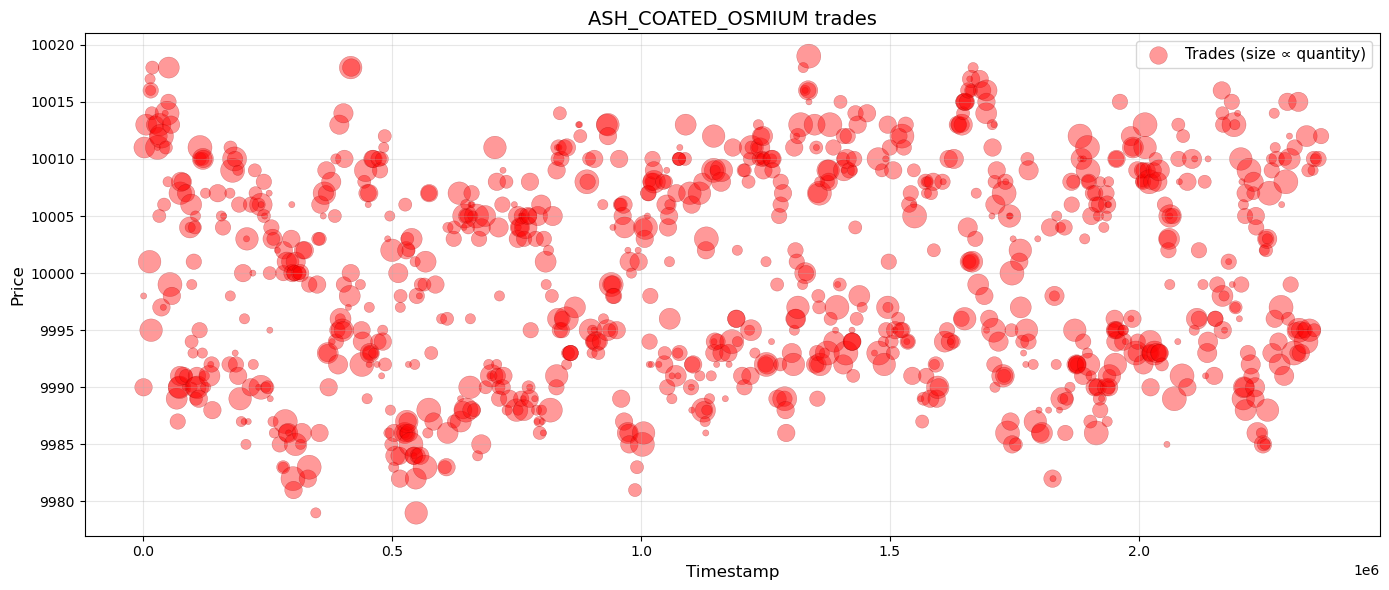

In [94]:
plot_trades(aco_trades[:1_000], 'ASH_COATED_OSMIUM trades')

In [95]:
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

def run_time_series_suite(series, change_point=False):
    results = {}
    clean = series.dropna()

    print('Running ADF test...')
    adf = adfuller(clean)
    results['ADF (Stationarity)'] = {'p-value': adf[1], 'Stationary': adf[1] < 0.05}

    print('Running KPSS test...')
    kpss_res = kpss(clean, regression='c', nlags='auto')
    results['KPSS (Trend Stationary)'] = {'p-value': kpss_res[1], 'Stationary': kpss_res[1] > 0.05}

    print('Running Ljung-Box test...')
    lb = acorr_ljungbox(clean, lags=[10], return_df=True)
    results['Ljung-Box (White Noise)'] = {'p-value': lb['lb_pvalue'].values[0], 'Is White Noise': lb['lb_pvalue'].values[0] > 0.05}

    if change_point:
        import ruptures as rpt
        print('Running Change-point Analysis...')
        algo = rpt.Pelt(model='rbf').fit(clean.values)
        cps = algo.predict(pen=10)
        results['Change Points Detected'] = len(cps) - 1

    print('Done!')
    results['Descriptive'] = {
        'Mean': clean.mean(), 'Std Dev': clean.std(),
        'Skewness': clean.skew(), 'Kurtosis': clean.kurt()
    }
    return results

In [96]:
from hurst import compute_Hc
from arch.unitroot import VarianceRatio
import scipy.stats as stats

def run_advanced_series_suite(series):
    results = {}
    clean = series.dropna()

    H, c, data = compute_Hc(clean, kind='price', simplified=True)
    results['Hurst Exponent'] = {
        'Value': H,
        'Interpretation': 'Mean-Reverting' if H < 0.45 else 'Trending' if H > 0.55 else 'Martingale/Random Walk'
    }

    vr = VarianceRatio(clean)
    results['Variance Ratio (Martingale)'] = {'p-value': vr.pvalue, 'Is Random Walk': vr.pvalue > 0.05}

    kurt = stats.kurtosis(clean)
    results['Volatility Profile'] = {
        'Excess Kurtosis': kurt, 'Has Fat Tails': kurt > 1, 'Std Dev': clean.std()
    }
    return results

In [97]:
print('=== ACO ===')
run_time_series_suite(aco_prices['mid_price'])

=== ACO ===
Running ADF test...
Running KPSS test...
Running Ljung-Box test...
Done!


/var/folders/z5/d2ytmy3d2h18qcqwb9v71w2m0000gq/T/ipykernel_7548/3506290995.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(clean, regression='c', nlags='auto')


{'ADF (Stationarity)': {'p-value': np.float64(4.2783808508349425e-07),
  'Stationary': np.True_},
 'KPSS (Trend Stationary)': {'p-value': np.float64(0.01),
  'Stationary': np.False_},
 'Ljung-Box (White Noise)': {'p-value': np.float64(0.0),
  'Is White Noise': np.False_},
 'Descriptive': {'Mean': np.float64(10000.204233581517),
  'Std Dev': 5.349695209772018,
  'Skewness': np.float64(-0.04508905939207592),
  'Kurtosis': np.float64(0.30329180215883644)}}

In [98]:
print('=== ACO advanced ===')
run_advanced_series_suite(aco_prices['mid_price'])

=== ACO advanced ===


{'Hurst Exponent': {'Value': np.float64(0.18278983542592042),
  'Interpretation': 'Mean-Reverting'},
 'Variance Ratio (Martingale)': {'p-value': np.float64(0.0),
  'Is Random Walk': np.False_},
 'Volatility Profile': {'Excess Kurtosis': np.float64(0.30304085268108594),
  'Has Fat Tails': np.False_,
  'Std Dev': 5.349695209772018}}

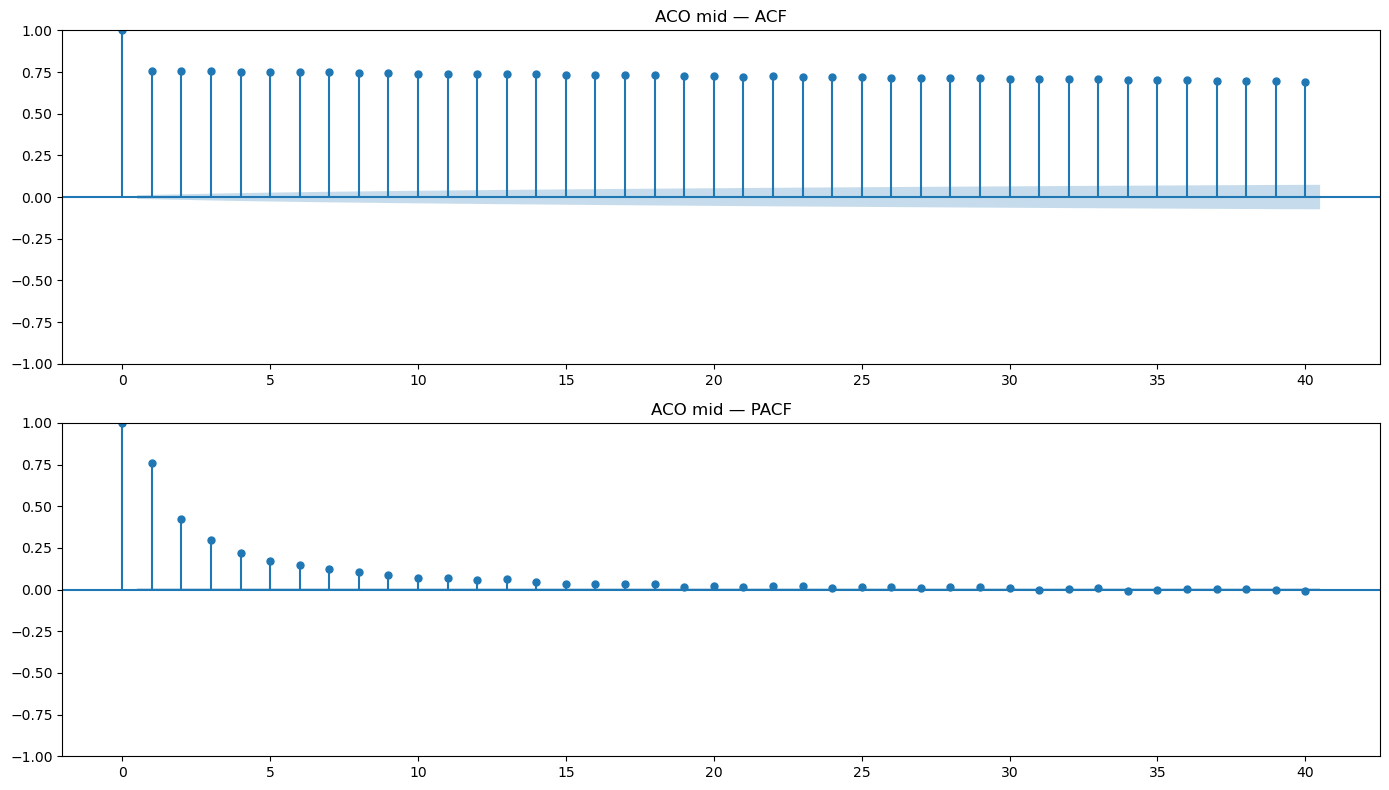

In [99]:
# ACF / PACF plots
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(aco_prices['mid_price'].dropna(),  lags=40, ax=axes[0], title='ACO mid — ACF')
plot_pacf(aco_prices['mid_price'].dropna(), lags=40, ax=axes[1], title='ACO mid — PACF')

plt.tight_layout()
plt.show()

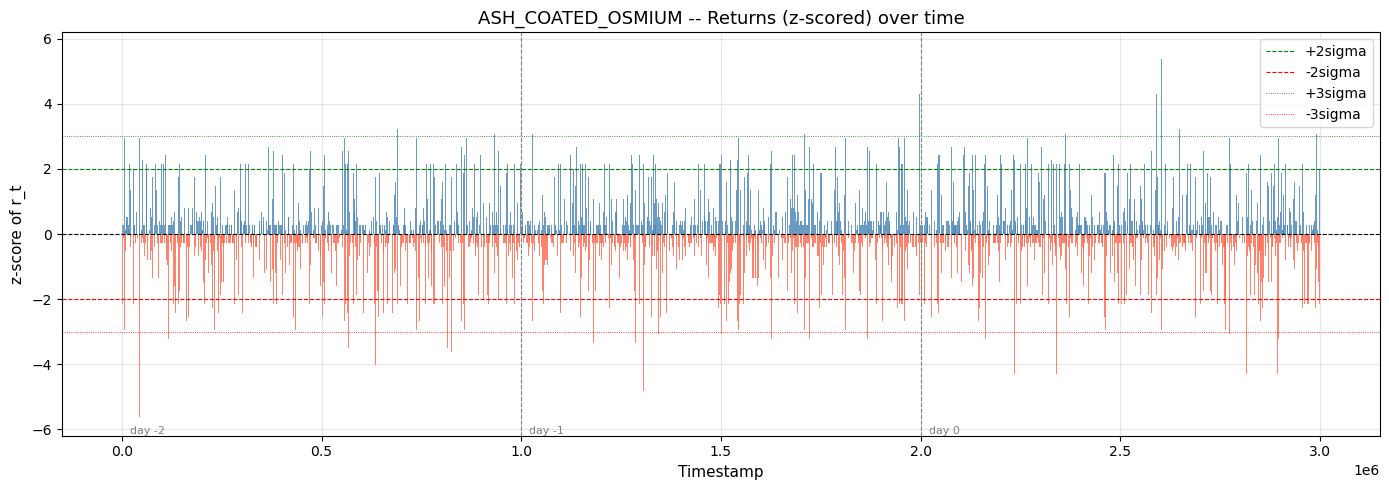

mu=-0.0001  sigma=3.7272
Non-zero returns: 21555 / 29951  (72.0%)
% |z| > 2: 11.4%
% |z| > 3: 0.9%


In [115]:
# ── Returns over time (z-scored) ─────────────────────────────────────────────
r_full = aco_prices['mid_price'].dropna().diff()
ts     = aco_prices['timestamp'].dropna()

mu_r  = r_full.mean()
sig_r = r_full.std()
z_r   = (r_full - mu_r) / sig_r

fig, ax = plt.subplots(figsize=(14, 5))
colors = ['steelblue' if v >= 0 else 'tomato' for v in z_r.fillna(0)]
ax.bar(ts, z_r, width=200, color=colors, alpha=0.8)
ax.axhline(0,   color='black', linewidth=0.8, linestyle='--')
ax.axhline( 2,  color='green', linewidth=0.8, linestyle='--', label='+2sigma')
ax.axhline(-2,  color='red',   linewidth=0.8, linestyle='--', label='-2sigma')
ax.axhline( 3,  color='green', linewidth=0.6, linestyle=':',  label='+3sigma')
ax.axhline(-3,  color='red',   linewidth=0.6, linestyle=':',  label='-3sigma')
for sep in [1_000_000, 2_000_000]:
    ax.axvline(sep, color='gray', lw=0.8, ls='--')
for i, label in enumerate(['day -2', 'day -1', 'day 0']):
    ax.text(i * 1_000_000 + 20_000, ax.get_ylim()[0], label, fontsize=8, color='gray', va='bottom')
ax.set_xlabel('Timestamp', fontsize=11)
ax.set_ylabel('z-score of r_t', fontsize=11)
ax.set_title('ASH_COATED_OSMIUM -- Returns (z-scored) over time', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'mu={mu_r:.4f}  sigma={sig_r:.4f}')
print(f'Non-zero returns: {(r_full != 0).sum()} / {len(r_full)}  ({(r_full != 0).mean()*100:.1f}%)')
print(f'% |z| > 2: {(z_r.abs() > 2).mean()*100:.1f}%')
print(f'% |z| > 3: {(z_r.abs() > 3).mean()*100:.1f}%')

## ASH_COATED_OSMIUM — Time Series Summary

| Test | Result | Interpretation |
|------|--------|----------------|
| **ADF** (stationarity) | p = 4.3e-7 ✓ | Price series is **stationary** |
| **KPSS** (trend-stationarity) | p = 0.01 ✗ | NOT trend-stationary (contradicts ADF — likely oscillates around a drifting mean) |
| **Ljung-Box** (white noise) | p ≈ 0 ✗ | **Not white noise** — significant autocorrelation structure present |
| **Hurst Exponent** | H = 0.183 | Strongly **mean-reverting** (H << 0.5) |
| **Variance Ratio** | p ≈ 0 ✗ | **Not a random walk** — predictable structure exists |
| **Kurtosis** | 0.30 | Thin tails, near-Gaussian returns |
| **Mean / Std** | μ ≈ 10000.2, σ ≈ 5.35 | Tight oscillation around a ~10000 fair value |

**Takeaway:** ACO is a strong mean-reversion candidate. Low Hurst, stationary price, and strong autocorrelation all point to a market-making / pairs-style strategy. The fair value is stable near 10000.

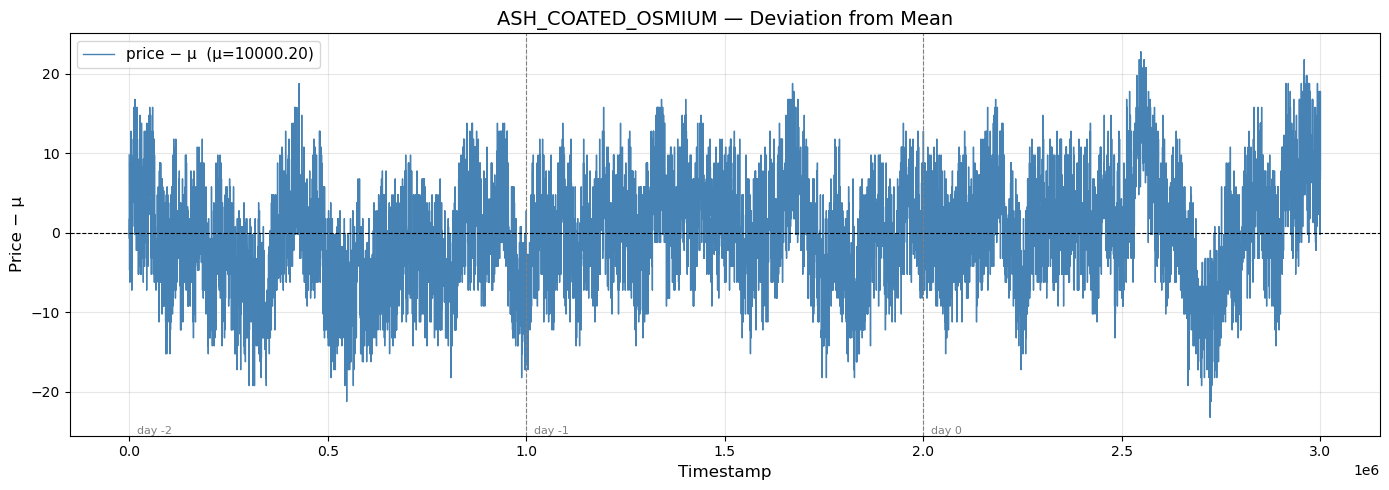

In [113]:
mu = aco_prices['mid_price'].mean()
deviation = aco_prices['mid_price'] - mu

plt.close('all')
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(aco_prices['timestamp'], deviation, linewidth=1.0, color='steelblue', label=f'price − μ  (μ={mu:.2f})')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
for sep in [1_000_000, 2_000_000]:
    ax.axvline(sep, color='gray', lw=0.8, ls='--')
for i, label in enumerate(['day -2', 'day -1', 'day 0']):
    ax.text(i * 1_000_000 + 20_000, ax.get_ylim()[0], label, fontsize=8, color='gray', va='bottom')
ax.set_xlabel('Timestamp', fontsize=12)
ax.set_ylabel('Price − μ', fontsize=12)
ax.set_title('ASH_COATED_OSMIUM — Deviation from Mean', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

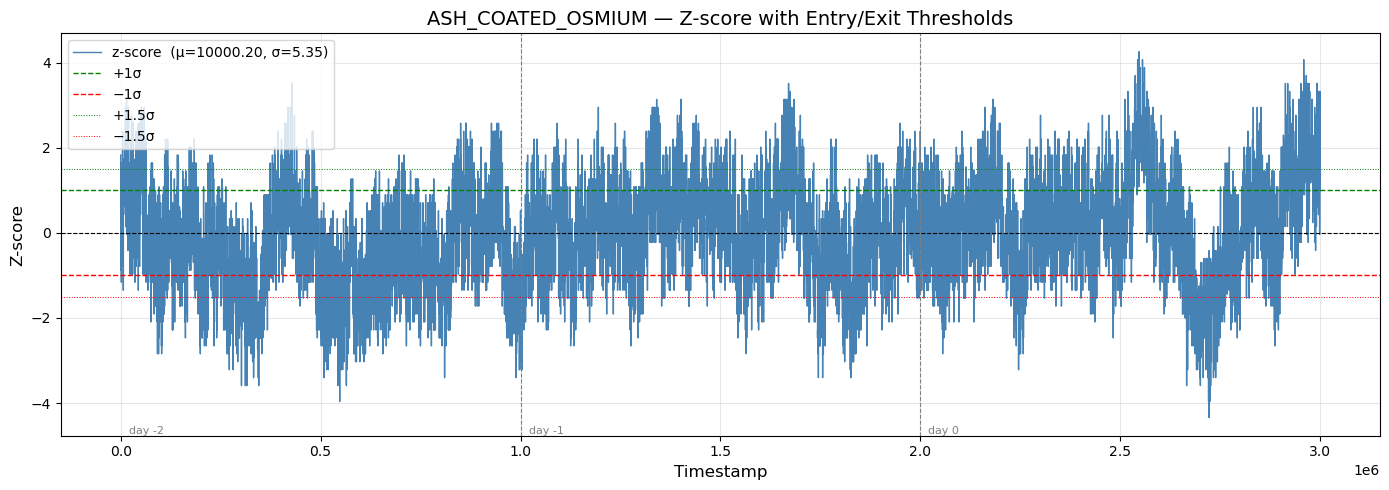

μ=10000.2042  σ=5.3497
% of time |z| > 1.0: 29.0%
% of time |z| > 1.5: 13.7%


In [101]:
mu    = aco_prices['mid_price'].mean()
sigma = aco_prices['mid_price'].std()
z     = (aco_prices['mid_price'] - mu) / sigma

plt.close('all')
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(aco_prices['timestamp'], z, linewidth=1.0, color='steelblue', label=f'z-score  (μ={mu:.2f}, σ={sigma:.2f})')
ax.axhline(0,    color='black', linewidth=0.8, linestyle='--')
ax.axhline( 1.0, color='green',  linewidth=1.0, linestyle='--', label='+1σ')
ax.axhline(-1.0, color='red',    linewidth=1.0, linestyle='--', label='−1σ')
ax.axhline( 1.5, color='green',  linewidth=0.7, linestyle=':',  label='+1.5σ')
ax.axhline(-1.5, color='red',    linewidth=0.7, linestyle=':',  label='−1.5σ')
for sep in [1_000_000, 2_000_000]:
    ax.axvline(sep, color='gray', lw=0.8, ls='--')
for i, label in enumerate(['day -2', 'day -1', 'day 0']):
    ax.text(i * 1_000_000 + 20_000, ax.get_ylim()[0], label, fontsize=8, color='gray', va='bottom')
ax.set_xlabel('Timestamp', fontsize=12)
ax.set_ylabel('Z-score', fontsize=12)
ax.set_title('ASH_COATED_OSMIUM — Z-score with Entry/Exit Thresholds', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'μ={mu:.4f}  σ={sigma:.4f}')
print(f'% of time |z| > 1.0: {(z.abs() > 1.0).mean()*100:.1f}%')
print(f'% of time |z| > 1.5: {(z.abs() > 1.5).mean()*100:.1f}%')

Kolmogorov-Smirnov test vs N(μ=10000.20, σ=5.35)
  KS statistic : 0.0534
  p-value      : 1.3874e-74
  Normal?      : No — reject normality


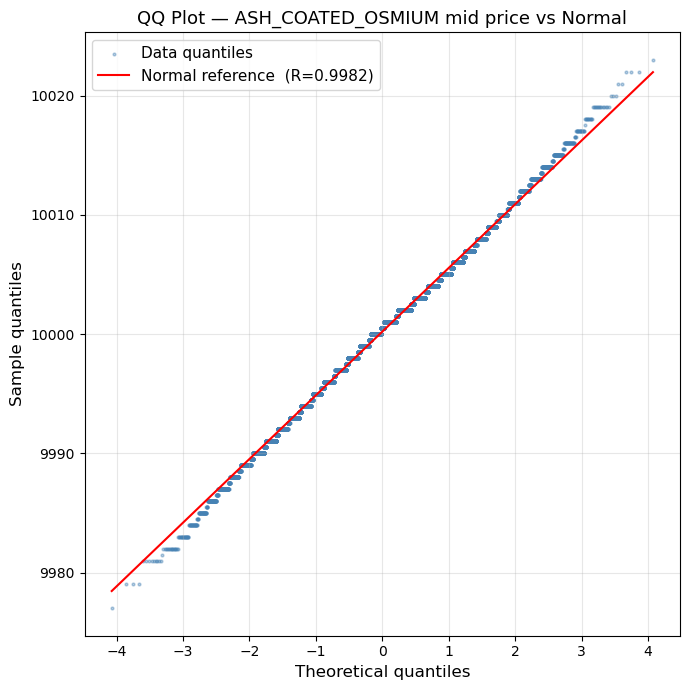

In [112]:
import scipy.stats as stats

clean = aco_prices['mid_price'].dropna()
mu_val    = clean.mean()
sigma_val = clean.std()

# ── KS test ──────────────────────────────────────────────────────────────────
ks_stat, ks_p = stats.kstest(clean, 'norm', args=(mu_val, sigma_val))
print(f'Kolmogorov-Smirnov test vs N(μ={mu_val:.2f}, σ={sigma_val:.2f})')
print(f'  KS statistic : {ks_stat:.4f}')
print(f'  p-value      : {ks_p:.4e}')
print(f'  Normal?      : {"Yes" if ks_p > 0.05 else "No — reject normality"}')

# ── QQ plot ───────────────────────────────────────────────────────────────────
plt.close('all')
fig, ax = plt.subplots(figsize=(7, 7))
(osm, osr), (slope, intercept, r) = stats.probplot(clean, dist='norm', plot=None)
ax.scatter(osm, osr, s=4, alpha=0.4, color='steelblue', label='Data quantiles')
line_x = np.array([osm.min(), osm.max()])
ax.plot(line_x, slope * line_x + intercept, color='red', linewidth=1.5, label=f'Normal reference  (R={r:.4f})')
ax.set_xlabel('Theoretical quantiles', fontsize=12)
ax.set_ylabel('Sample quantiles', fontsize=12)
ax.set_title('QQ Plot — ASH_COATED_OSMIUM mid price vs Normal', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

n = 29949 pairs
Lag-1 correlation (φ): -0.4952


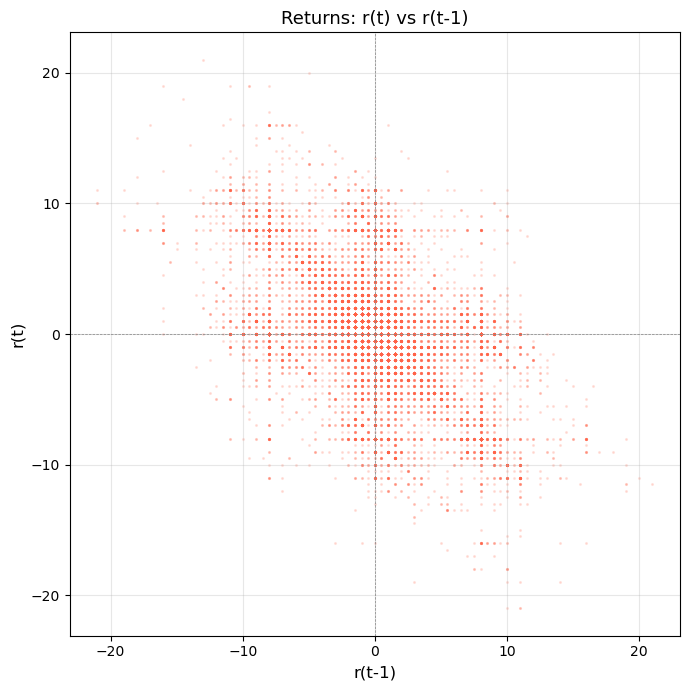

In [106]:
# ── Bivariate returns: (r(t), r(t-1)) ────────────────────────────────────────
r = aco_prices['mid_price'].dropna().reset_index(drop=True).diff().dropna()
biv = pd.DataFrame({'r(t)': r.values[1:], 'r(t-1)': r.values[:-1]})

print(f'n = {len(biv)} pairs')
print(f'Lag-1 correlation (φ): {biv.corr().iloc[0,1]:.4f}')

# ── Scatter ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(biv['r(t-1)'], biv['r(t)'], s=1.5, alpha=0.15, color='tomato')
ax.axhline(0, color='gray', lw=0.5, ls='--')
ax.axvline(0, color='gray', lw=0.5, ls='--')
ax.set_xlabel('r(t-1)', fontsize=12)
ax.set_ylabel('r(t)', fontsize=12)
ax.set_title('Returns: r(t) vs r(t-1)', fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

n = 29950 pairs
Lag-1 correlation φ = 0.7573  (AR(1) mean-reversion coefficient)
P(t):  KS p=1.316e-74  SW p=3.113e-07  non-normal (likely discreteness)
P(t-1):  KS p=1.377e-74  SW p=3.228e-07  non-normal (likely discreteness)

Mardia's BVN Test — (P(t), P(t-1))
  Skewness  b1p=0.0037  Chi²=18.36 (df=4)  p=1.047e-03  fail
  Kurtosis  b2p=11.6226  expected=8       z=78.37   p=0.000e+00  fail


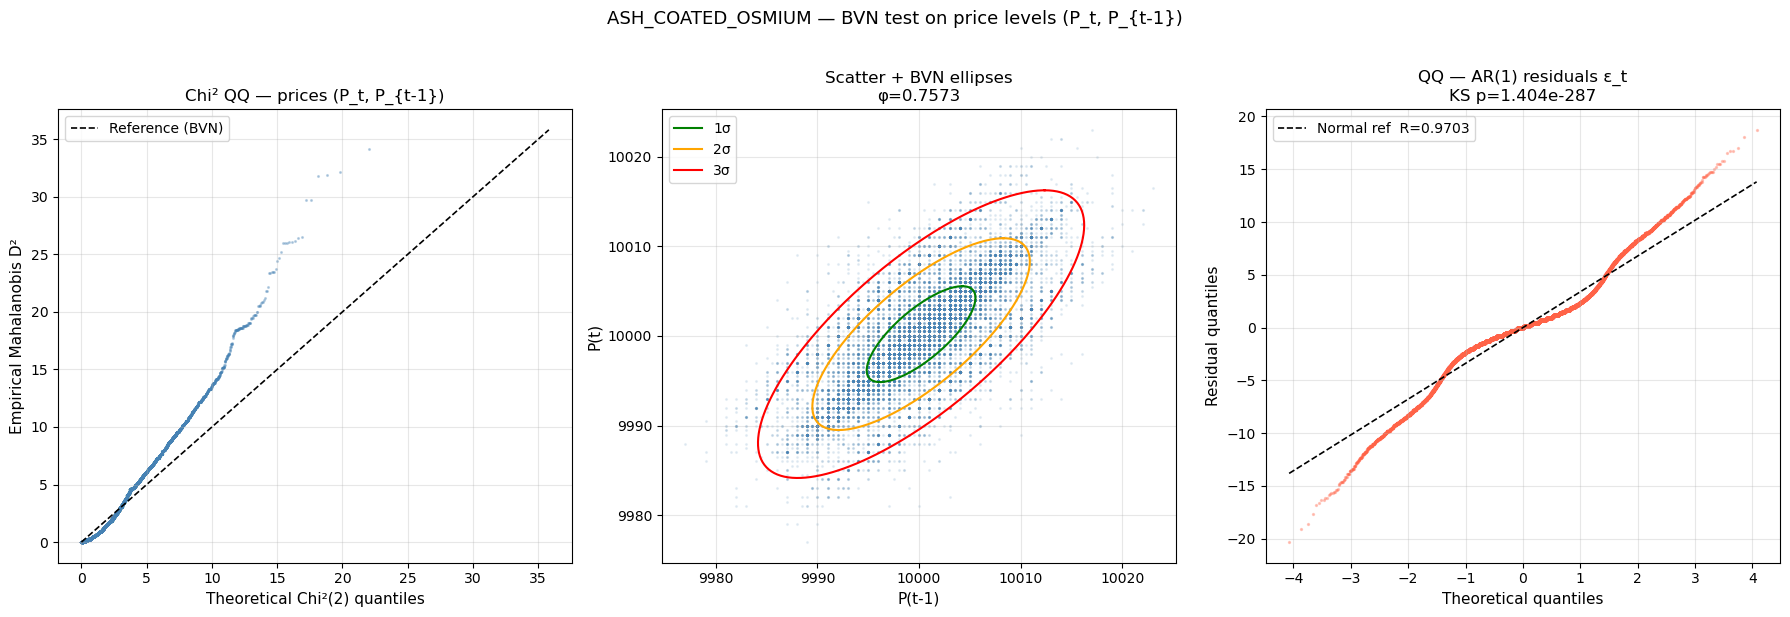

In [110]:
# ── BVN test on (P_t, P_{t-1}) ───────────────────────────────────────────────
p = aco_prices['mid_price'].dropna().reset_index(drop=True)
price_biv = pd.DataFrame({'P(t)': p.values[1:], 'P(t-1)': p.values[:-1]})
n_p = len(price_biv)

phi_hat = price_biv.corr().iloc[0, 1]
print(f'n = {n_p} pairs')
print(f'Lag-1 correlation φ = {phi_hat:.4f}  (AR(1) mean-reversion coefficient)')

# ── Marginal normality of P(t) ────────────────────────────────────────────────
for col in ['P(t)', 'P(t-1)']:
    v = price_biv[col].values
    ks_s, ks_p = stats.kstest(v, 'norm', args=(v.mean(), v.std()))
    sw_s, sw_p = stats.shapiro(v[:4999])
    print(f'{col}:  KS p={ks_p:.3e}  SW p={sw_p:.3e}  {"normal" if ks_p>0.05 and sw_p>0.05 else "non-normal (likely discreteness)"}')

# ── Mardia's test on (P_t, P_{t-1}) ──────────────────────────────────────────
X_p   = price_biv.values
X_pc  = X_p - X_p.mean(axis=0)
S_p   = np.cov(X_p.T)
S_pi  = np.linalg.inv(S_p)
D_p   = X_pc @ S_pi @ X_pc.T

b1p_p     = (D_p ** 3).mean()
df_s      = 2 * 3 * 4 / 6   # p*(p+1)*(p+2)/6, p=2
chi2_s    = n_p * b1p_p / 6
p_s       = 1 - stats.chi2.cdf(chi2_s, df=df_s)

b2p_p     = np.mean(np.diag(D_p) ** 2)
kmu       = 2 * 4              # p*(p+2)
kstd      = np.sqrt(8 * 2 * 4 / n_p)
z_k       = (b2p_p - kmu) / kstd
p_k       = 2 * (1 - stats.norm.cdf(abs(z_k)))

print()
print("Mardia's BVN Test — (P(t), P(t-1))")
print(f'  Skewness  b1p={b1p_p:.4f}  Chi²={chi2_s:.2f} (df={df_s:.0f})  p={p_s:.3e}  {"pass" if p_s>0.05 else "fail"}')
print(f'  Kurtosis  b2p={b2p_p:.4f}  expected={kmu}       z={z_k:.2f}   p={p_k:.3e}  {"pass" if p_k>0.05 else "fail"}')

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Chi² QQ of Mahalanobis distances
D2_p   = np.sort(np.diag(D_p))
chi2_q = stats.chi2.ppf((np.arange(1, n_p + 1) - 0.5) / n_p, df=2)
ax = axes[0]
ax.scatter(chi2_q, D2_p, s=1.5, alpha=0.3, color='steelblue')
lim = max(chi2_q.max(), D2_p.max()) * 1.05
ax.plot([0, lim], [0, lim], 'k--', lw=1.2, label='Reference (BVN)')
ax.set_xlabel('Theoretical Chi²(2) quantiles', fontsize=11)
ax.set_ylabel('Empirical Mahalanobis D²', fontsize=11)
ax.set_title('Chi² QQ — prices (P_t, P_{t-1})', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Scatter + BVN ellipses
ax = axes[1]
ax.scatter(price_biv['P(t-1)'], price_biv['P(t)'], s=1.5, alpha=0.1, color='steelblue')
mu_p2 = X_p.mean(axis=0)
L_p   = np.linalg.cholesky(S_p)
theta = np.linspace(0, 2 * np.pi, 300)
circle = np.stack([np.cos(theta), np.sin(theta)])
for nsig, col, lbl in [(1, 'green', '1σ'), (2, 'orange', '2σ'), (3, 'red', '3σ')]:
    e = mu_p2[:, None] + nsig * L_p @ circle
    ax.plot(e[1], e[0], color=col, lw=1.5, label=lbl)
ax.set_xlabel('P(t-1)', fontsize=11)
ax.set_ylabel('P(t)', fontsize=11)
ax.set_title(f'Scatter + BVN ellipses\nφ={phi_hat:.4f}', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Residuals from AR(1) fit: e_t = P_t - (μ + φ*(P_{t-1} − μ))
mu_fit  = price_biv['P(t)'].mean()
resid   = price_biv['P(t)'].values - (mu_fit + phi_hat * (price_biv['P(t-1)'].values - mu_fit))
ks_r, ks_rp = stats.kstest(resid, 'norm', args=(resid.mean(), resid.std()))
ax = axes[2]
(osm_r, osr_r), (sl_r, ic_r, rv_r) = stats.probplot(resid, dist='norm', plot=None)
ax.scatter(osm_r, osr_r, s=2, alpha=0.3, color='tomato')
lx = np.array([osm_r.min(), osm_r.max()])
ax.plot(lx, sl_r * lx + ic_r, 'k--', lw=1.2, label=f'Normal ref  R={rv_r:.4f}')
ax.set_xlabel('Theoretical quantiles', fontsize=11)
ax.set_ylabel('Residual quantiles', fontsize=11)
ax.set_title(f'QQ — AR(1) residuals ε_t\nKS p={ks_rp:.3e}', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle('ASH_COATED_OSMIUM — BVN test on price levels (P_t, P_{t-1})', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

r(t):  μ=0.0002  σ=3.7268
KS:    stat=0.1767  p=0.000e+00  ✗ — check plots (discreteness inflates KS)


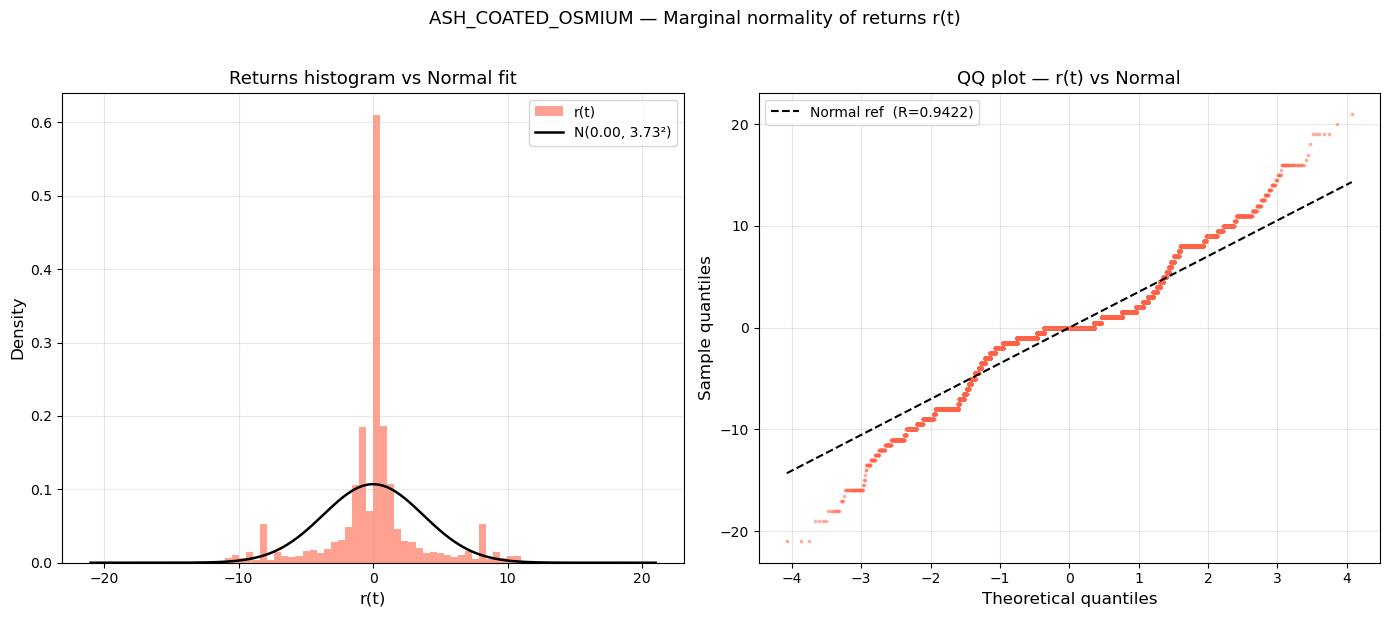

In [107]:
# ── Marginal normality of r(t) — necessary condition for BVN ─────────────────
r_clean = biv['r(t)'].values
mu_r, sigma_r = r_clean.mean(), r_clean.std()

ks_stat, ks_p = stats.kstest(r_clean, 'norm', args=(mu_r, sigma_r))
print(f'r(t):  μ={mu_r:.4f}  σ={sigma_r:.4f}')
print(f'KS:    stat={ks_stat:.4f}  p={ks_p:.3e}  {"✓" if ks_p > 0.05 else "✗ — check plots (discreteness inflates KS)"}')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogram vs fitted normal
ax = axes[0]
counts, bins, _ = ax.hist(r_clean, bins=80, density=True, color='tomato', alpha=0.6, label='r(t)')
x_fit = np.linspace(bins[0], bins[-1], 400)
ax.plot(x_fit, stats.norm.pdf(x_fit, mu_r, sigma_r), 'k-', lw=1.8, label=f'N({mu_r:.2f}, {sigma_r:.2f}²)')
ax.set_xlabel('r(t)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Returns histogram vs Normal fit', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# QQ plot
ax = axes[1]
(osm, osr), (slope, intercept, r_val) = stats.probplot(r_clean, dist='norm', plot=None)
ax.scatter(osm, osr, s=3, alpha=0.4, color='tomato')
lx = np.array([osm.min(), osm.max()])
ax.plot(lx, slope * lx + intercept, 'k--', lw=1.5, label=f'Normal ref  (R={r_val:.4f})')
ax.set_xlabel('Theoretical quantiles', fontsize=12)
ax.set_ylabel('Sample quantiles', fontsize=12)
ax.set_title('QQ plot — r(t) vs Normal', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle('ASH_COATED_OSMIUM — Marginal normality of returns r(t)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

n=29949  (Shapiro-Wilk subsample=4999)
Combination                    SW stat        SW p   KS stat        KS p  Normal?
--------------------------------------------------------------------------------
r(t)                            0.8917   1.475e-50    0.1767   0.000e+00  no
r(t-1)                          0.8884   4.565e-51    0.1767   0.000e+00  no
r(t) + r(t-1)                   0.8911   1.203e-50    0.1718   0.000e+00  no
r(t) - r(t-1)                   0.9232   7.126e-45    0.1395   0.000e+00  no
r(t) + 2·r(t-1)                 0.9256   2.283e-44    0.1371   0.000e+00  no
2·r(t) - r(t-1)                 0.9193   1.155e-45    0.1388   0.000e+00  no
r(t) + 0.5·r(t-1)               0.9212   2.779e-45    0.1376   0.000e+00  no
0.5·r(t) - r(t-1)               0.9176   5.338e-46    0.1375   0.000e+00  no


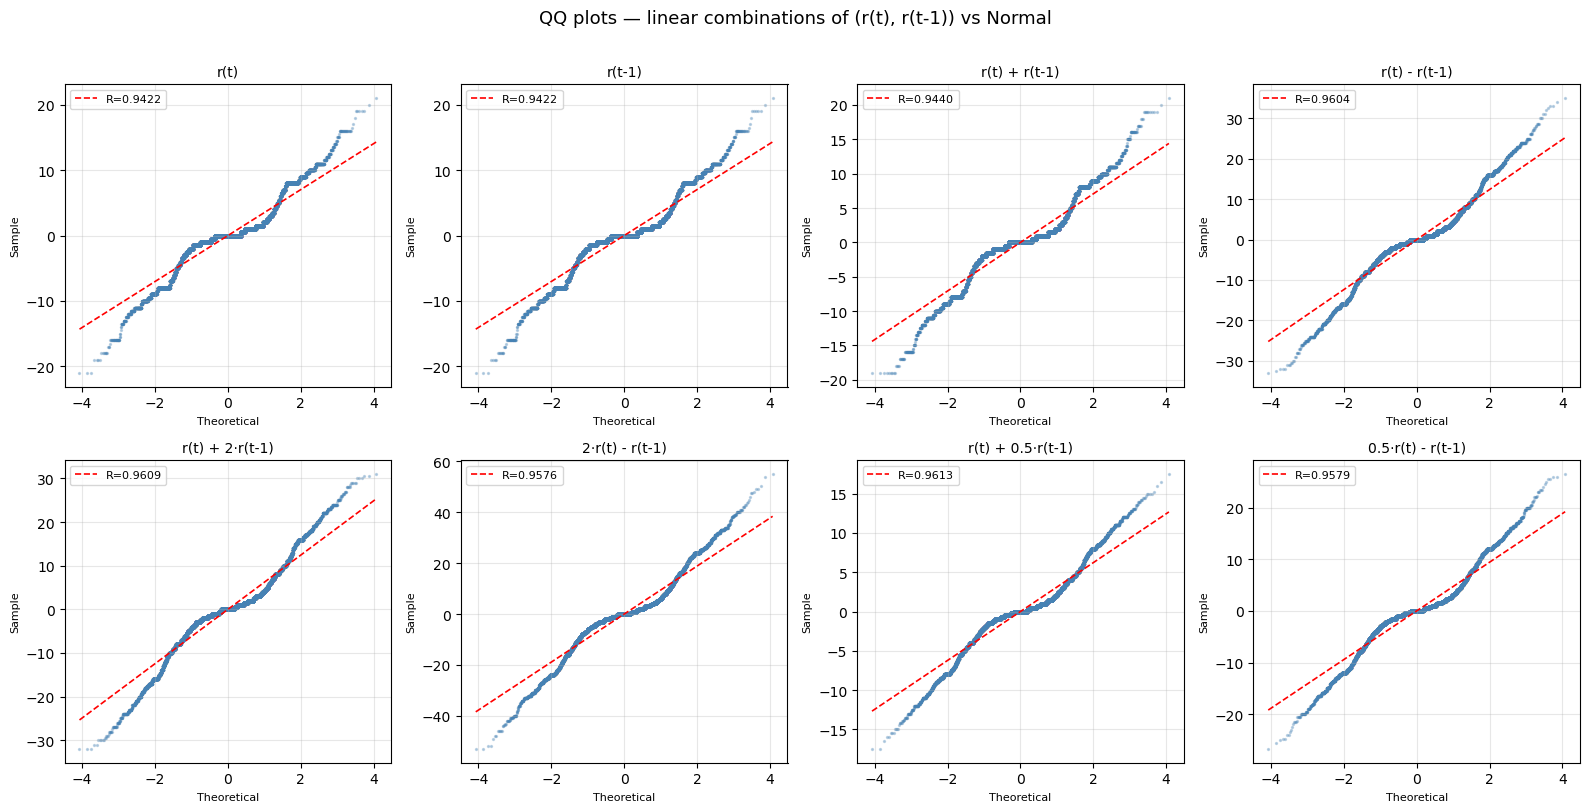

In [108]:
# ── Linear combinations of (r(t), r(t-1)) — normality ────────────────────────
# Under BVN any linear combination a*r(t) + b*r(t-1) must be normal.
# Test several (a, b) pairs with Shapiro-Wilk (n<5000) and KS tests + QQ plots.

combos = [
    (1,  0,  'r(t)'),
    (0,  1,  'r(t-1)'),
    (1,  1,  'r(t) + r(t-1)'),
    (1, -1,  'r(t) - r(t-1)'),
    (1,  2,  'r(t) + 2·r(t-1)'),
    (2, -1,  '2·r(t) - r(t-1)'),
    (1,  0.5,'r(t) + 0.5·r(t-1)'),
    (0.5,-1, '0.5·r(t) - r(t-1)'),
]

rt  = biv['r(t)'].values
rt1 = biv['r(t-1)'].values
n   = len(rt)
sample_size = min(n, 4999)   # Shapiro-Wilk limit
rng = np.random.default_rng(0)
idx = rng.choice(n, size=sample_size, replace=False)

print(f"n={n}  (Shapiro-Wilk subsample={sample_size})")
print(f"{'Combination':<28}  {'SW stat':>8}  {'SW p':>10}  {'KS stat':>8}  {'KS p':>10}  Normal?")
print('-' * 80)

sw_results = []
for a, b, label in combos:
    lc      = a * rt + b * rt1
    lc_sub  = lc[idx]
    mu_lc   = lc_sub.mean()
    sig_lc  = lc_sub.std()
    sw_s, sw_p = stats.shapiro(lc_sub)
    ks_s, ks_p = stats.kstest(lc, 'norm', args=(lc.mean(), lc.std()))
    flag = "yes" if (sw_p > 0.05 and ks_p > 0.05) else "no"
    print(f"{label:<28}  {sw_s:>8.4f}  {sw_p:>10.3e}  {ks_s:>8.4f}  {ks_p:>10.3e}  {flag}")
    sw_results.append((label, lc))

# ── QQ grid ───────────────────────────────────────────────────────────────────
ncols = 4
nrows = (len(combos) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for i, (label, lc) in enumerate(sw_results):
    ax = axes[i]
    (osm, osr), (slope, intercept, r_val) = stats.probplot(lc, dist='norm', plot=None)
    ax.scatter(osm, osr, s=2, alpha=0.3, color='steelblue')
    lx = np.array([osm.min(), osm.max()])
    ax.plot(lx, slope * lx + intercept, 'r--', lw=1.2, label=f'R={r_val:.4f}')
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('Theoretical', fontsize=8)
    ax.set_ylabel('Sample', fontsize=8)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

for j in range(len(combos), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('QQ plots — linear combinations of (r(t), r(t-1)) vs Normal', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Mardia's Bivariate Normality Test — (r(t), r(t-1))
  Skewness  b1p=0.0023  Chi²=11.68 (df=4)  p=1.991e-02  ✗
  Kurtosis  b2p=15.7633  expected=8       z=167.94   p=0.000e+00  ✗  (zero-inflation drives this)


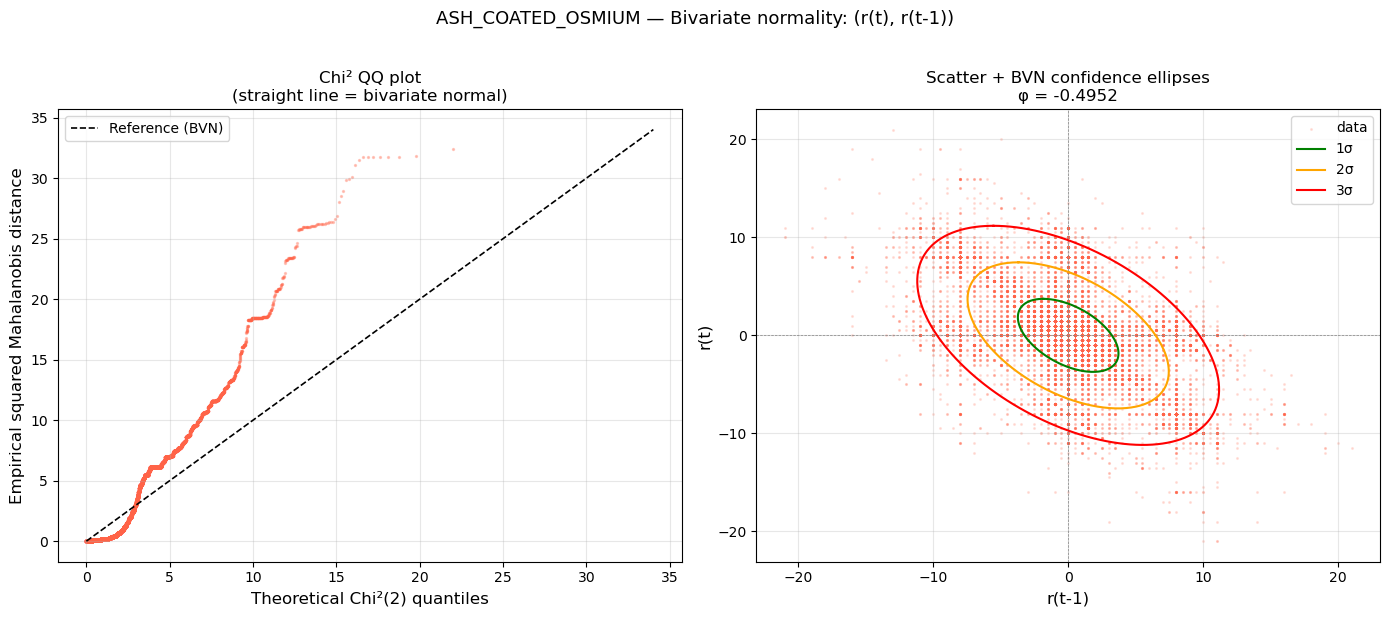

In [ ]:
# ── Bivariate normality: Mardia's test ───────────────────────────────────────
X     = biv.values
n, p  = X.shape        # p=2
X_c   = X - X.mean(axis=0)
S     = np.cov(X.T)
S_inv = np.linalg.inv(S)
D     = X_c @ S_inv @ X_c.T   # n×n Mahalanobis cross-matrix

# Skewness
b1p       = (D**3).mean()
df_skew   = p * (p + 1) * (p + 2) / 6
chi2_stat = n * b1p / 6
p_skew    = 1 - stats.chi2.cdf(chi2_stat, df=df_skew)

# Kurtosis
b2p       = np.mean(np.diag(D)**2)
kurt_mean = p * (p + 2)
kurt_std  = np.sqrt(8 * p * (p + 2) / n)
z_kurt    = (b2p - kurt_mean) / kurt_std
p_kurt    = 2 * (1 - stats.norm.cdf(abs(z_kurt)))

print("Mardia's Bivariate Normality Test — (r(t), r(t-1))")
print(f'  Skewness  b1p={b1p:.4f}  Chi²={chi2_stat:.2f} (df={df_skew:.0f})  p={p_skew:.3e}  {"✓" if p_skew>0.05 else "✗"}')
print(f'  Kurtosis  b2p={b2p:.4f}  expected={kurt_mean}       z={z_kurt:.2f}   p={p_kurt:.3e}  {"✓" if p_kurt>0.05 else "✗  (zero-inflation drives this)"}')

# ── Chi² QQ plot of squared Mahalanobis distances ─────────────────────────────
# Under BVN: D²_i ~ Chi²(2). Straight line = bivariate normal.
D2_sq    = np.diag(D)
sorted_D = np.sort(D2_sq)
chi2_q   = stats.chi2.ppf((np.arange(1, n + 1) - 0.5) / n, df=2)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.scatter(chi2_q, sorted_D, s=2, alpha=0.3, color='tomato')
lim = max(chi2_q.max(), sorted_D.max()) * 1.05
ax.plot([0, lim], [0, lim], 'k--', lw=1.2, label='Reference (BVN)')
ax.set_xlabel('Theoretical Chi²(2) quantiles', fontsize=12)
ax.set_ylabel('Empirical squared Mahalanobis distance', fontsize=12)
ax.set_title('Chi² QQ plot\n(straight line = bivariate normal)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# ── 2D scatter with confidence ellipses ──────────────────────────────────────
ax = axes[1]
ax.scatter(biv['r(t-1)'], biv['r(t)'], s=1.5, alpha=0.15, color='tomato', label='data')
ax.axhline(0, color='gray', lw=0.5, ls='--')
ax.axvline(0, color='gray', lw=0.5, ls='--')

theta = np.linspace(0, 2 * np.pi, 300)
circle = np.stack([np.cos(theta), np.sin(theta)])
L = np.linalg.cholesky(S)
mu2 = X.mean(axis=0)
for nsig, col, lbl in [(1,'green','1σ'), (2,'orange','2σ'), (3,'red','3σ')]:
    e = mu2[:, None] + nsig * L @ circle
    ax.plot(e[1], e[0], color=col, lw=1.5, label=lbl)

phi = biv.corr().iloc[0, 1]
ax.set_xlabel('r(t-1)', fontsize=12)
ax.set_ylabel('r(t)', fontsize=12)
ax.set_title(f'Scatter + BVN confidence ellipses\nφ = {phi:.4f}', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle('ASH_COATED_OSMIUM — Bivariate normality: (r(t), r(t-1))', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

k (reversion speed) = 0.242744
mu (implied)        = 10000.2036
R^2                 = 0.121387
residual variance   = 12.205611
residual std        = 3.493653


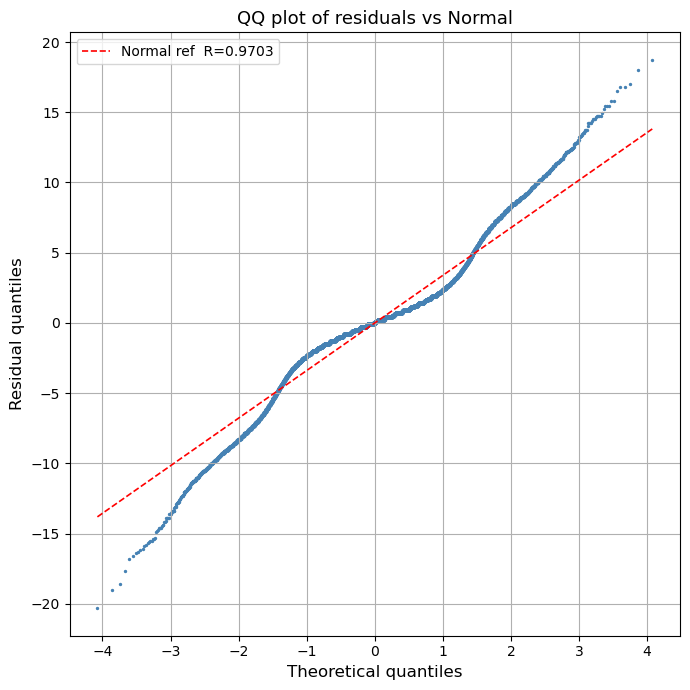

In [146]:
# dX_t = k(mu - X_t) + epsilon  =>  dX_t = a + b*X_t + epsilon
# k = -b,  mu = -a/b
from sklearn.linear_model import LinearRegression

p  = aco_prices['mid_price'].dropna().values
dX = p[1:] - p[:-1]
X  = p[:-1].reshape(-1, 1)

reg   = LinearRegression(fit_intercept=True).fit(X, dX)
b, a  = reg.coef_[0], reg.intercept_
k     = -b
mu    = -a / b
resid = dX - reg.predict(X)

print(f'k (reversion speed) = {k:.6f}')
print(f'mu (implied)        = {mu:.4f}')
print(f'R^2                 = {reg.score(X, dX):.6f}')
print(f'residual variance   = {resid.var():.6f}')
print(f'residual std        = {resid.std():.6f}')

fig, ax = plt.subplots(figsize=(7, 7))
(osm, osr), (slope, intercept, r) = stats.probplot(resid, dist='norm', plot=None)
ax.scatter(osm, osr, s=2, alpha=1, color='steelblue')
lx = np.array([osm.min(), osm.max()])
ax.plot(lx, slope * lx + intercept, 'r--', lw=1.2, label=f'Normal ref  R={r:.4f}')
ax.set_xlabel('Theoretical quantiles', fontsize=12)
ax.set_ylabel('Residual quantiles', fontsize=12)
ax.set_title('QQ plot of residuals vs Normal', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=1)
plt.tight_layout()
plt.show()


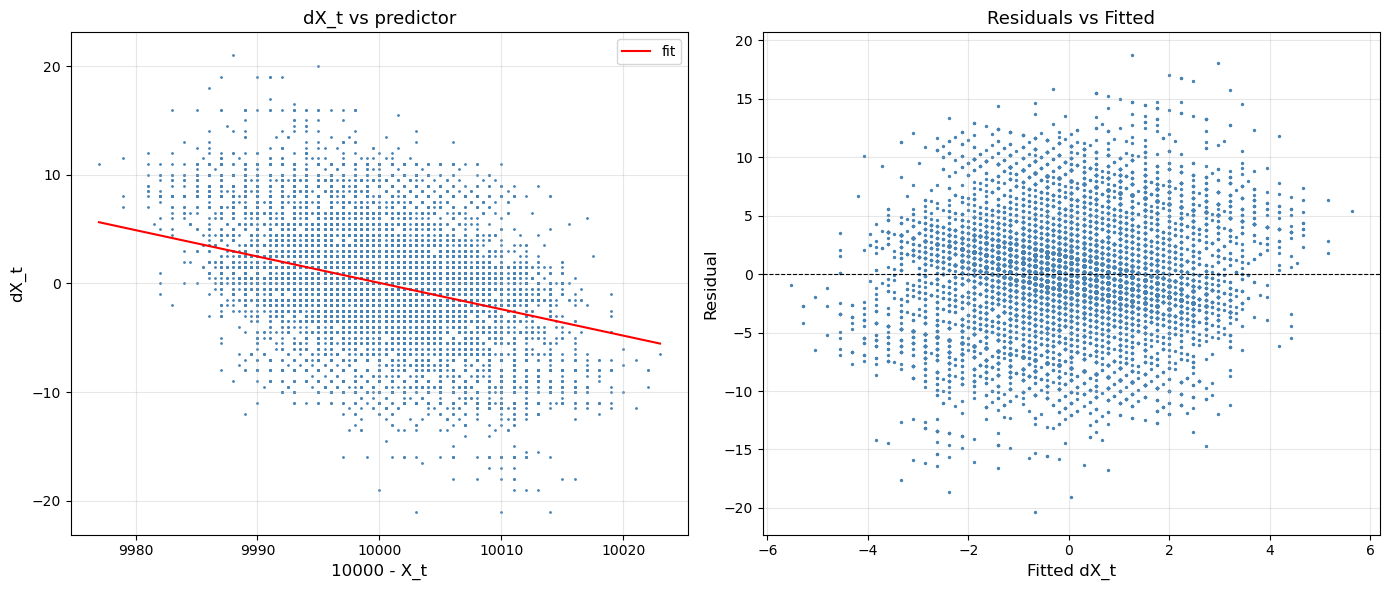

In [145]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.scatter(X, dX, s=1, alpha=1, color='steelblue')
ax.plot(sorted(X.flatten()), reg.predict(np.array(sorted(X.flatten())).reshape(-1,1)), color='red', lw=1.5, label='fit')
ax.set_xlabel('10000 - X_t', fontsize=12)
ax.set_ylabel('dX_t', fontsize=12)
ax.set_title('dX_t vs predictor', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.scatter(reg.predict(X), resid, s=2, alpha=1, color='steelblue')
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_xlabel('Fitted dX_t', fontsize=12)
ax.set_ylabel('Residual', fontsize=12)
ax.set_title('Residuals vs Fitted', fontsize=13)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
